# 03 — ฝึกสอนแบบจำลอง (Training)

Notebook นี้ฝึกสอนโมเดลจริงตามสถาปัตยกรรมและกลยุทธ์ที่ออกแบบไว้ใน `02_model_transfer_learning.ipynb`:
1. โหลดภาพที่ cache ไว้ (จาก notebook 01) และโมเดล MobileNetV2 transfer learning (จาก notebook 02)
2. **เฟส 1**: เทรนเฉพาะ head ใหม่ (backbone frozen)
3. **เฟส 2**: Fine-tune โดย unfreeze top-30 layers ท้ายของ backbone ด้วย learning rate ต่ำ
4. รายงาน Accuracy/Loss ของ Train และ Validation ต่อ epoch พร้อมกราฟ และบันทึกน้ำหนักโมเดลที่ดีที่สุด

**หมายเหตุเรื่องเวลาเทรน:** เครื่องที่ใช้รันโปรเจคนี้เป็น Windows โดยไม่มี GPU ที่ TensorFlow 2.15 รองรับแบบ native (ดูเหตุผลใน notebook 02) การเทรนทั้งหมดจึงรันบน CPU (16 cores) ซึ่งใช้เวลานานกว่าการใช้ GPU มาก — เราจึงจำกัดจำนวน epoch ให้อยู่ในระดับที่เหมาะสมและใช้ `EarlyStopping` เพื่อหยุดอัตโนมัติเมื่อโมเดลเริ่ม overfit


In [1]:
%matplotlib inline
import sys, json, time
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))

import numpy as np
import tensorflow as tf
from tensorflow import keras

from src.data_utils import MODELS_DIR, CACHE_DIR
from src.model_utils import build_transfer_model, unfreeze_top_layers, sparse_categorical_focal_loss
from src.pipeline import make_dataset, IMG_SIZE
from src.viz_utils import plot_training_history, savefig
import matplotlib.pyplot as plt

print("TensorFlow:", tf.__version__)
print("GPUs visible to TensorFlow:", tf.config.list_physical_devices("GPU"), "(empty = CPU-only run, expected on native Windows with TF 2.15)")


TensorFlow: 2.15.0
GPUs visible to TensorFlow: [] (empty = CPU-only run, expected on native Windows with TF 2.15)


## 1. โหลดข้อมูลที่ cache ไว้และ class mapping

In [2]:
train_data = np.load(CACHE_DIR / "train_96.npz")
val_data = np.load(CACHE_DIR / "val_96.npz")
train_images, train_labels = train_data["images"], train_data["labels"]
val_images, val_labels = val_data["images"], val_data["labels"]

with open(CACHE_DIR / "class_maps.json", encoding="utf-8") as f:
    class_maps = json.load(f)
class_to_idx = class_maps["class_to_idx"]
idx_to_class = class_maps["idx_to_class"]
NUM_CLASSES = len(class_to_idx)

print(f"Train: {train_images.shape}, labels {train_labels.shape}")
print(f"Val:   {val_images.shape}, labels {val_labels.shape}")
print(f"จำนวนคลาส: {NUM_CLASSES}")


Train: (50162, 96, 96, 3), labels (50162,)
Val:   (12545, 96, 96, 3), labels (12545,)
จำนวนคลาส: 72


## 2. Hyperparameters และ Callbacks

| Hyperparameter | ค่าที่ใช้ | เหตุผล |
|---|---|---|
| Backbone | MobileNetV2 (ImageNet pretrained) | เบา เร็ว เหมาะกับ CPU (ดูเหตุผลเต็มใน notebook 02) |
| Input size | 96×96×3 | ตรงกับน้ำหนัก pretrained ของ Keras โดยตรง |
| Batch size | 128 | สมดุลระหว่างความเร็ว/step กับความนิ่งของ gradient บน CPU |
| Loss function | Focal Loss (gamma=2.0) | จัดการ class imbalance รุนแรง (>5,000 เท่า) — ดูเหตุผลเต็มใน notebook 01 |
| Optimizer | Adam | ปรับ learning rate ต่อพารามิเตอร์อัตโนมัติ เหมาะกับการ fine-tune backbone pretrained |
| Learning rate (เฟส 1: frozen head) | 1e-3 | head เป็น layer ใหม่ล้วน เทรนเร็วได้โดยไม่กระทบ backbone ที่ frozen อยู่ |
| Learning rate (เฟส 2: fine-tune) | 1e-5 | ต่ำกว่าเฟส 1 มาก เพื่อไม่ทำลาย weight pretrained ของ backbone ที่ unfreeze บางส่วน |
| Epochs (สูงสุด) | เฟส 1: 8, เฟส 2: 6 | จำกัดเวลาเทรนบน CPU ให้สมเหตุสมผล ร่วมกับ EarlyStopping |

**Callbacks ที่ใช้ในทั้งสองเฟส:**
- `EarlyStopping(monitor="val_accuracy", patience=3, restore_best_weights=True)` — หยุดเทรนอัตโนมัติเมื่อ validation accuracy ไม่ดีขึ้น และย้อนกลับไปใช้ weight ที่ดีที่สุดที่เคยเจอ
- `ModelCheckpoint(monitor="val_accuracy", save_best_only=True)` — บันทึกน้ำหนักโมเดลที่ทำ validation accuracy ดีที่สุดไว้ที่ `outputs/models/best_model.keras` ตลอดการเทรน (ทับซ้อนกันได้ระหว่างสองเฟส เพราะ monitor ค่าเดียวกัน)
- `ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=2, min_lr=1e-7)` — ลด learning rate ลงครึ่งหนึ่งเมื่อ validation loss หยุดดีขึ้น ช่วยให้โมเดลปรับละเอียดขึ้นในช่วงท้ายของการเทรน


In [3]:
BATCH_SIZE = 128
MODELS_DIR.mkdir(parents=True, exist_ok=True)
BEST_MODEL_PATH = MODELS_DIR / "best_model.keras"

train_ds = make_dataset(train_images, train_labels, batch_size=BATCH_SIZE, training=True)
val_ds = make_dataset(val_images, val_labels, batch_size=BATCH_SIZE, training=False)

def make_callbacks():
    return [
        keras.callbacks.EarlyStopping(monitor="val_accuracy", patience=3, restore_best_weights=True, verbose=1),
        keras.callbacks.ModelCheckpoint(str(BEST_MODEL_PATH), monitor="val_accuracy", save_best_only=True, verbose=1),
        keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=2, min_lr=1e-7, verbose=1),
    ]

model, backbone = build_transfer_model("mobilenetv2", num_classes=NUM_CLASSES, freeze_backbone=True)
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss=sparse_categorical_focal_loss(gamma=2.0),
    metrics=["accuracy"],
)
model.summary()


Model: "mobilenetv2_transfer"


_________________________________________________________________


 Layer (type)                Output Shape              Param #   


 input_2 (InputLayer)        [(None, 96, 96, 3)]       0         


 preprocess (Lambda)         (None, 96, 96, 3)         0         


...

 predictions (Dense)         (None, 72)                18504     


Total params: 2604424 (9.94 MB)


Trainable params: 346440 (1.32 MB)


Non-trainable params: 2257984 (8.61 MB)


_________________________________________________________________


## 3. เฟส 1 — เทรนเฉพาะ Head (Backbone Frozen)

In [4]:
t0 = time.time()
history1 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=8,
    callbacks=make_callbacks(),
    verbose=2,
)
print(f"เฟส 1 ใช้เวลา {time.time() - t0:.0f} วินาที")


Epoch 1/8



Epoch 1: val_accuracy improved from -inf to 0.30163, saving model to C:\Users\Acer\Desktop\deep\outputs\models\best_model.keras


392/392 - 223s - loss: 1.4743 - accuracy: 0.5855 - val_loss: 2.6321 - val_accuracy: 0.3016 - lr: 0.0010 - 223s/epoch - 570ms/step


Epoch 2/8



Epoch 2: val_accuracy improved from 0.30163 to 0.42439, saving model to C:\Users\Acer\Desktop\deep\outputs\models\best_model.keras


...

392/392 - 254s - loss: 0.1965 - accuracy: 0.8790 - val_loss: 0.5716 - val_accuracy: 0.7045 - lr: 0.0010 - 254s/epoch - 649ms/step


Epoch 8/8



Epoch 8: val_accuracy improved from 0.70450 to 0.72810, saving model to C:\Users\Acer\Desktop\deep\outputs\models\best_model.keras


392/392 - 222s - loss: 0.1815 - accuracy: 0.8849 - val_loss: 0.5270 - val_accuracy: 0.7281 - lr: 0.0010 - 222s/epoch - 566ms/step


เฟส 1 ใช้เวลา 2040 วินาที


## 4. เฟส 2 — Fine-tuning (Unfreeze Top-30 Layers ของ Backbone)

Unfreeze เฉพาะ layer ท้าย ๆ ของ backbone (ตามที่อธิบายไว้ใน notebook 02) แล้วเทรนต่อด้วย learning rate ต่ำมาก (1e-5) เพื่อปรับ feature ระดับสูงให้เข้ากับลักษณะเฉพาะของตัวอักษรไทย โดยไม่ทำลาย feature ทั่วไปที่ pretrained มาอย่างดีแล้ว


In [5]:
unfreeze_top_layers(backbone, n_layers=30)
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-5),
    loss=sparse_categorical_focal_loss(gamma=2.0),
    metrics=["accuracy"],
)

t0 = time.time()
history2 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=6,
    callbacks=make_callbacks(),
    verbose=2,
)
print(f"เฟส 2 ใช้เวลา {time.time() - t0:.0f} วินาที")


Epoch 1/6



Epoch 1: val_accuracy improved from -inf to 0.81674, saving model to C:\Users\Acer\Desktop\deep\outputs\models\best_model.keras


392/392 - 142s - loss: 0.2446 - accuracy: 0.8496 - val_loss: 0.3175 - val_accuracy: 0.8167 - lr: 1.0000e-05 - 142s/epoch - 362ms/step


Epoch 2/6



Epoch 2: val_accuracy improved from 0.81674 to 0.83491, saving model to C:\Users\Acer\Desktop\deep\outputs\models\best_model.keras


...

392/392 - 142s - loss: 0.1362 - accuracy: 0.9071 - val_loss: 0.2600 - val_accuracy: 0.8406 - lr: 1.0000e-05 - 142s/epoch - 362ms/step


Epoch 6/6



Epoch 6: val_accuracy improved from 0.84097 to 0.85420, saving model to C:\Users\Acer\Desktop\deep\outputs\models\best_model.keras


392/392 - 140s - loss: 0.1302 - accuracy: 0.9113 - val_loss: 0.2257 - val_accuracy: 0.8542 - lr: 1.0000e-05 - 140s/epoch - 358ms/step


เฟส 2 ใช้เวลา 846 วินาที


## 5. กราฟ Accuracy/Loss ตลอดการเทรน (ทั้งสองเฟสรวมกัน)

Saved figure -> C:\Users\Acer\Desktop\deep\outputs\figures\03_training_curves.png


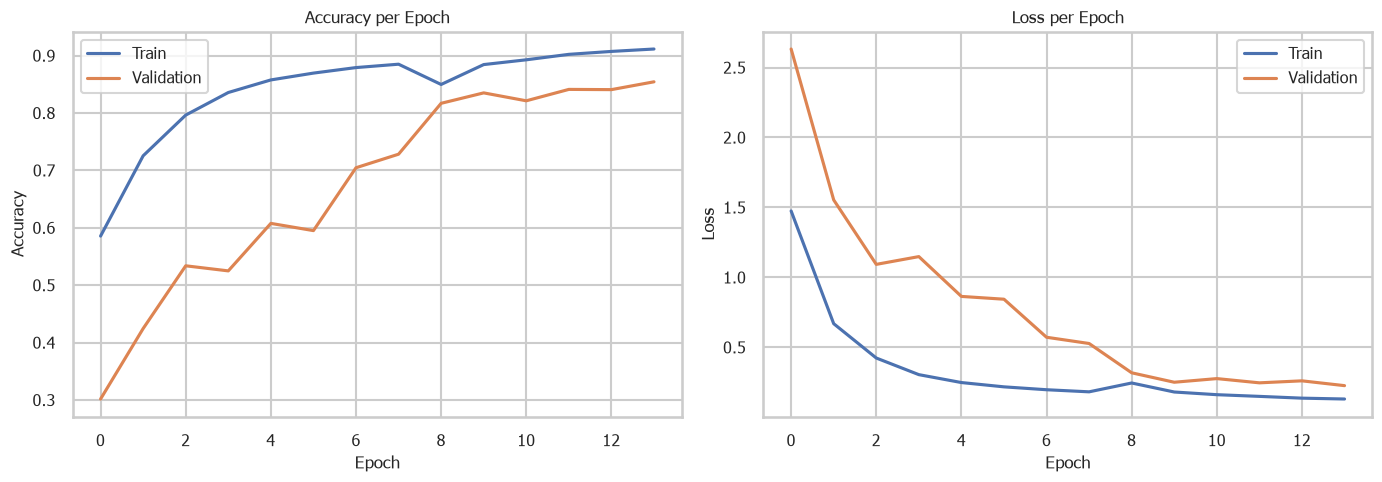

Saved figure -> C:\Users\Acer\Desktop\deep\outputs\figures\03_training_curves.png


WindowsPath('C:/Users/Acer/Desktop/deep/outputs/figures/03_training_curves.png')

In [6]:
combined_history = {
    "accuracy": history1.history["accuracy"] + history2.history["accuracy"],
    "val_accuracy": history1.history["val_accuracy"] + history2.history["val_accuracy"],
    "loss": history1.history["loss"] + history2.history["loss"],
    "val_loss": history1.history["val_loss"] + history2.history["val_loss"],
}
n_phase1 = len(history1.history["accuracy"])

fig = plot_training_history(combined_history, name="03_training_curves.png")
for ax in fig.axes:
    ax.axvline(n_phase1 - 0.5, color="gray", linestyle="--", linewidth=1, label="เริ่ม fine-tune")
    ax.legend()
savefig(fig, "03_training_curves.png")


In [7]:
final_train_acc = combined_history["accuracy"][-1]
final_val_acc = combined_history["val_accuracy"][-1]
best_val_acc = max(combined_history["val_accuracy"])
best_epoch = combined_history["val_accuracy"].index(best_val_acc) + 1

print(f"Train accuracy (epoch สุดท้าย)      = {final_train_acc:.4f}")
print(f"Validation accuracy (epoch สุดท้าย)  = {final_val_acc:.4f}")
print(f"Validation accuracy ที่ดีที่สุด      = {best_val_acc:.4f} (epoch ที่ {best_epoch})")
print(f"\nน้ำหนักโมเดลที่ดีที่สุด (val_accuracy สูงสุด) ถูกบันทึกไว้ที่: {BEST_MODEL_PATH}")


Train accuracy (epoch สุดท้าย)      = 0.9113
Validation accuracy (epoch สุดท้าย)  = 0.8542
Validation accuracy ที่ดีที่สุด      = 0.8542 (epoch ที่ 14)

น้ำหนักโมเดลที่ดีที่สุด (val_accuracy สูงสุด) ถูกบันทึกไว้ที่: C:\Users\Acer\Desktop\deep\outputs\models\best_model.keras


**สรุปผล:** ตัวเลข Train/Validation accuracy ข้างต้นคือค่าความถูกต้อง (Accuracy Rate) ของแบบจำลองตามที่กำหนดในเกณฑ์การประเมิน `ModelCheckpoint` เก็บเฉพาะน้ำหนักที่ให้ validation accuracy สูงสุดตลอดการเทรน (ไม่ใช่ของ epoch สุดท้ายเสมอไป) และนี่คือไฟล์น้ำหนักที่ notebook `04_evaluation_prediction.ipynb` จะโหลดไปใช้ประเมินผลและทำนายชุดทดสอบต่อ


## สรุป Notebook 03

- เทรนโมเดล MobileNetV2 transfer learning แบบ 2 เฟส: freeze head (8 epochs) → fine-tune top-30 layers (สูงสุด 6 epochs)
- ใช้ Focal Loss จัดการ class imbalance, Adam optimizer, และ callback ครบ 3 แบบ (EarlyStopping, ModelCheckpoint, ReduceLROnPlateau)
- รายงาน Train/Validation accuracy ต่อ epoch เป็นกราฟและตัวเลขสรุปด้านบน
- บันทึกน้ำหนักโมเดลที่ดีที่สุดไว้ที่ `outputs/models/best_model.keras` สำหรับใช้ต่อใน notebook 04
